<a href="https://colab.research.google.com/github/imkonna/Project-KGX/blob/main/Baselines_updated_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fingerprint Baselines for Molecular Toxicity Prediction

This notebook implements the classical baseline part of the KGX project.
The main goal is to evaluate whether traditional molecular fingerprint models can provide strong comparison points for the GNN-based toxicity models.

The baseline pipeline is:

**SMILES → Morgan fingerprints → Random Forest / XGBoost → toxicity prediction**

Main contributions of this notebook:

1. reusable Morgan fingerprint featurization with RDKit;
2. Random Forest and XGBoost baselines for binary toxicity prediction;
3. imbalance-aware baselines for highly imbalanced datasets such as ClinTox and Tox21;
4. endpoint-wise evaluation over all 12 Tox21 toxicity endpoints;
5. PR-AUC, toxic-class recall, toxic-class F1 and balanced accuracy in addition to ROC-AUC;
6. sampling experiments and threshold tuning for minority-class detection;
7. LD50 regression baselines using Random Forest and XGBoost regressors.

The motivation is that ROC-AUC alone can be misleading in imbalanced toxicity datasets. A model may rank molecules reasonably well but still fail to detect the rare toxic cases at the default decision threshold.

## 0. Setup — Colab-safe package installation

**Recommended workflow in Google Colab:**

1. Run the setup cell below once.
2. The runtime will restart automatically after installation.
3. Run the notebook again from the beginning. The setup cell will detect the installation flag and continue.

This avoids the common `numpy.dtype size changed` / pandas-numpy binary incompatibility error.

If you already have a clean environment, you can set `RUN_SETUP = False`.

In [ ]:
# Colab-safe setup cell.
# It installs a compatible scientific stack and PyTDC without letting PyTDC downgrade packages.
# On the first run, it restarts the runtime automatically. On the second run, it continues.

from pathlib import Path
import os
import subprocess
import sys

RUN_SETUP = True
FORCE_REINSTALL = False
SETUP_FLAG = Path(".baseline_deps_installed")

if RUN_SETUP and (FORCE_REINSTALL or not SETUP_FLAG.exists()):
    print("Installing compatible baseline dependencies...")

    # 1) Core compiled scientific stack.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall", "--no-cache-dir",
        "numpy>=2.0,<2.3",
        "pandas>=2.2.3",
        "scipy>=1.11",
        "scikit-learn>=1.4.2",
        "xgboost>=2.0",
        "imbalanced-learn>=0.14.0",
        "matplotlib>=3.8",
        "rdkit>=2024.3",
    ])

    # 2) PyTDC dependencies that are needed for loading the datasets.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--no-cache-dir",
        "setuptools<76",
        "fuzzywuzzy>=0.18",
        "python-Levenshtein>=0.20",
        "openpyxl>=3.0",
        "huggingface_hub>=0.20",
        "tqdm",
        "requests",
    ])

    # 3) Install PyTDC without dependencies, so it does not downgrade numpy/pandas/sklearn.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--no-deps", "PyTDC"
    ])

    SETUP_FLAG.write_text("installed")
    print("\nPackages installed. Restarting the runtime now...")
    print("After the restart, run the notebook again from the beginning.")
    os.kill(os.getpid(), 9)
else:
    print("Setup skipped or already completed. Continuing with imports...")
    print("If imports still fail, set FORCE_REINSTALL = True and run this cell again.")


Setup skipped or already completed. Continuing with imports...
If imports still fail, set FORCE_REINSTALL = True and run this cell again.


In [ ]:
import os
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from tdc.single_pred import Tox
from tdc.utils import retrieve_label_name_list

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = "../data"

FP_RADIUS = 2
FP_BITS = 2048

print("Environment versions:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Imbalanced-learn:", imblearn.__version__)

RUN_FULL_TOX21 = True           # Set to False for a quick test with only the first Tox21 endpoint.
RUN_SAMPLING_EXPERIMENTS = True # Set to False if SMOTE/undersampling experiments are too slow.

OUTPUT_DIR = Path("outputs/baselines")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Environment versions:
NumPy: 2.2.6
Pandas: 3.0.3
Scikit-learn: 1.8.0
Imbalanced-learn: 0.14.1


## Notebook roadmap

The notebook is organized as follows:

1. load the toxicity datasets from TDC;
2. convert SMILES strings into Morgan fingerprints;
3. inspect class imbalance across datasets;
4. train standard and imbalance-aware Random Forest / XGBoost baselines;
5. evaluate all Tox21 endpoints separately;
6. study threshold tuning and sampling strategies;
7. run LD50 regression baselines;
8. summarize the best baseline results for the report and poster.


## 1. Load toxicity datasets

The project focuses on toxicity prediction datasets from TDC.

Binary classification tasks:

- AMES
- hERG_Karim
- ClinTox
- DILI
- Tox21 endpoints

Regression task:

- LD50_Zhu

In [ ]:
# Single-task binary classification datasets
split_ames = Tox(name="AMES", path=DATA_PATH).get_split()
split_herg = Tox(name="hERG_Karim", path=DATA_PATH).get_split()
split_clintox = Tox(name="ClinTox", path=DATA_PATH).get_split()
split_dili = Tox(name="DILI", path=DATA_PATH).get_split()

# Regression dataset
split_ld50 = Tox(name="LD50_Zhu", path=DATA_PATH).get_split()

classification_splits = {
    "AMES": split_ames,
    "hERG_Karim": split_herg,
    "ClinTox": split_clintox,
    "DILI": split_dili,
}

# Tox21 contains multiple endpoints. TDC loads them one target at a time.
tox21_label_names = retrieve_label_name_list("Tox21")
print("Tox21 endpoints:")
print(tox21_label_names)

if RUN_FULL_TOX21:
    tox21_splits = {}
    for label in tox21_label_names:
        tox21_splits[label] = Tox(name="Tox21", label_name=label, path=DATA_PATH).get_split()
else:
    first_label = tox21_label_names[0]
    tox21_splits = {first_label: Tox(name="Tox21", label_name=first_label, path=DATA_PATH).get_split()}

print(f"Loaded {len(classification_splits)} single-task datasets and {len(tox21_splits)} Tox21 endpoint(s).")

Downloading...
100%|██████████| 344k/344k [00:00<00:00, 4.08MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 885k/885k [00:00<00:00, 6.69MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 110k/110k [00:00<00:00, 1.93MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 26.7k/26.7k [00:00<00:00, 1.06MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 707k/707k [00:00<00:00, 5.19MiB/s]
Loading...
Done!
Downloading...


Tox21 endpoints:
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


100%|██████████| 712k/712k [00:00<00:00, 5.62MiB/s]
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded 4 single-task datasets and 12 Tox21 endpoint(s).


## 2. Fingerprint featurization

The baselines use **Morgan fingerprints**. This provides a classical molecular representation that can be compared against the GNN models.

In [ ]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=FP_RADIUS,
    fpSize=FP_BITS,
)


def smiles_to_morgan_fp(smiles, n_bits=FP_BITS):
    """Convert a SMILES string into a binary Morgan fingerprint vector."""
    mol = Chem.MolFromSmiles(str(smiles))
    arr = np.zeros((n_bits,), dtype=np.int8)

    if mol is None:
        return arr

    fp = morgan_generator.GetFingerprint(mol)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def split_to_fingerprints(split):
    """Convert a TDC split dictionary into fingerprint arrays."""
    X_train = np.array([smiles_to_morgan_fp(s) for s in split["train"]["Drug"]])
    y_train = split["train"]["Y"].values.astype(float)

    X_test = np.array([smiles_to_morgan_fp(s) for s in split["test"]["Drug"]])
    y_test = split["test"]["Y"].values.astype(float)

    if "valid" in split and len(split["valid"]) > 0:
        X_valid = np.array([smiles_to_morgan_fp(s) for s in split["valid"]["Drug"]])
        y_valid = split["valid"]["Y"].values.astype(float)
    else:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train,
            y_train,
            test_size=0.15,
            stratify=y_train,
            random_state=RANDOM_STATE,
        )

    return X_train, y_train, X_valid, y_valid, X_test, y_test

### Why Morgan fingerprints?

Morgan fingerprints are a standard fixed-length representation for molecules. They encode local atomic neighborhoods into a binary vector and are widely used with classical machine learning models.

In this project, they serve as a non-GNN comparison point. If a GNN outperforms these baselines, it suggests that learning directly from graph structure provides additional value. If fingerprint baselines remain competitive, this indicates that classical molecular representations still capture useful chemical information.


## 3. Dataset imbalance overview

For imbalanced datasets, **accuracy and ROC-AUC are not enough**. We also report:

- PR-AUC;
- toxic-class recall;
- toxic-class F1;
- balanced accuracy.

In [ ]:
def binary_balance_summary(name, split):
    """Summarize class imbalance for a binary TDC dataset."""
    rows = []
    for part in ["train", "valid", "test"]:
        if part not in split or len(split[part]) == 0:
            continue

        y = split[part]["Y"].values.astype(int)
        n = len(y)
        positives = int(np.sum(y == 1))
        negatives = int(np.sum(y == 0))
        pos_rate = positives / n if n else np.nan
        neg_to_pos = negatives / positives if positives else np.inf

        rows.append({
            "dataset": name,
            "split": part,
            "n": n,
            "safe_0": negatives,
            "toxic_1": positives,
            "positive_rate": pos_rate,
            "neg_to_pos_ratio": neg_to_pos,
        })
    return rows


balance_rows = []
for dataset_name, split in classification_splits.items():
    balance_rows.extend(binary_balance_summary(dataset_name, split))

for label, split in tox21_splits.items():
    balance_rows.extend(binary_balance_summary(f"Tox21::{label}", split))

balance_df = pd.DataFrame(balance_rows)
balance_df.sort_values(["positive_rate", "dataset", "split"]).head(20)

,dataset,split,n,safe_0,toxic_1,positive_rate,neg_to_pos_ratio
32,Tox21::NR-PPAR-gamma,test,1290,1257,33,0.025581,38.090909
30,Tox21::NR-PPAR-gamma,train,4515,4384,131,0.029014,33.465649
16,Tox21::NR-AR-LBD,valid,676,656,20,0.029586,32.800000
17,Tox21::NR-AR-LBD,test,1352,1311,41,0.030325,31.975610
31,Tox21::NR-PPAR-gamma,valid,645,623,22,0.034109,28.318182
36,Tox21::SR-ATAD5,train,4951,4771,180,0.036356,26.505556
15,Tox21::NR-AR-LBD,train,4730,4554,176,0.037209,25.875000
38,Tox21::SR-ATAD5,test,1414,1360,54,0.038190,25.185185
12,Tox21::NR-AR,train,5086,4878,208,0.040897,23.451923
37,Tox21::SR-ATAD5,valid,707,677,30,0.042433,22.566667


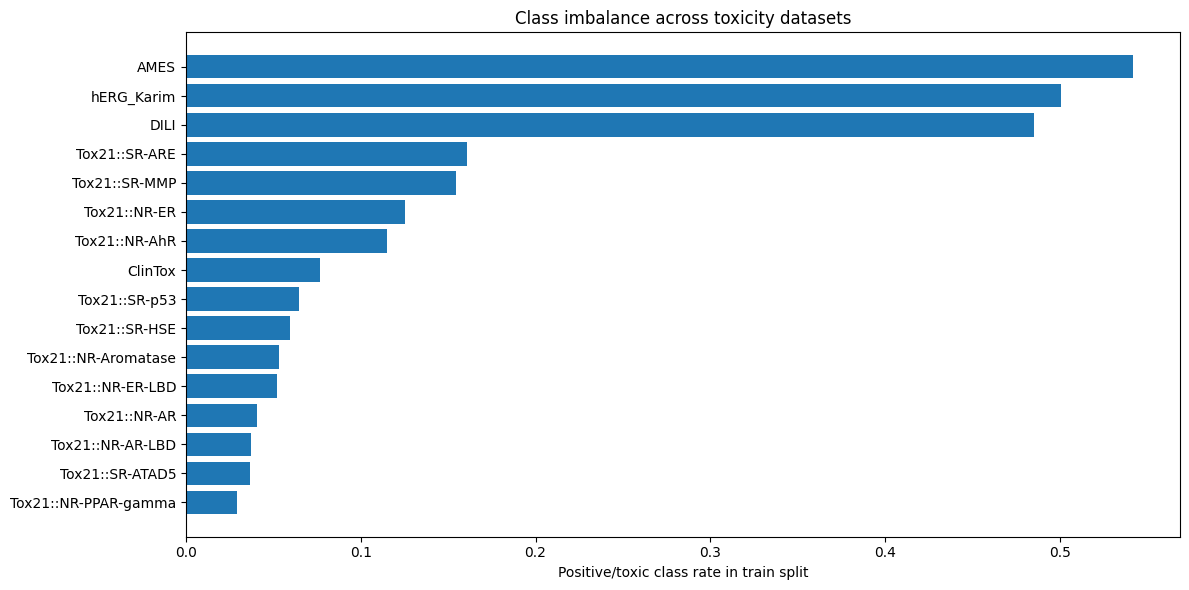

In [ ]:
# Plot train-set imbalance. This figure is useful for the report/poster.
train_balance = balance_df[balance_df["split"] == "train"].copy()
train_balance = train_balance.sort_values("positive_rate")

plt.figure(figsize=(12, 6))
plt.barh(train_balance["dataset"], train_balance["positive_rate"])
plt.xlabel("Positive/toxic class rate in train split")
plt.title("Class imbalance across toxicity datasets")
plt.tight_layout()
plt.show()

### Interpretation: class imbalance

The imbalance overview shows that not all toxicity tasks have the same difficulty. AMES, hERG and DILI are relatively more balanced, while ClinTox and several Tox21 endpoints contain very few positive/toxic examples.

This is important because in highly imbalanced datasets a model can achieve high accuracy by predicting the majority class. For this reason, the analysis below focuses not only on ROC-AUC, but also on PR-AUC, toxic-class recall and toxic-class F1.


## 4. Metrics and helper functions

In [ ]:
def safe_roc_auc(y_true, probabilities):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def safe_pr_auc(y_true, probabilities):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, probabilities)


def evaluate_binary_predictions(y_true, probabilities, threshold=0.5):
    """Return a compact metric dictionary for a binary classifier."""
    y_true = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "pr_auc": safe_pr_auc(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "toxic_precision": precision_score(y_true, predictions, zero_division=0),
        "toxic_recall": recall_score(y_true, predictions, zero_division=0),
        "toxic_f1": f1_score(y_true, predictions, zero_division=0),
    }


def find_best_threshold(y_true_valid, valid_probabilities, metric="f1"):
    """Tune the classification threshold on the validation set only."""
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_threshold = 0.5
    best_score = -1

    y_true_valid = np.asarray(y_true_valid).astype(int)

    for threshold in thresholds:
        pred = (valid_probabilities >= threshold).astype(int)

        if metric == "recall":
            score = recall_score(y_true_valid, pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true_valid, pred)
        else:
            score = f1_score(y_true_valid, pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold, best_score


def compute_scale_pos_weight(y_train):
    """XGBoost imbalance weight: number of negatives / number of positives."""
    y_train = np.asarray(y_train).astype(int)
    positives = np.sum(y_train == 1)
    negatives = np.sum(y_train == 0)
    return float(negatives / positives) if positives > 0 else 1.0


def print_binary_report(name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    print(f"\n{name}")
    print("=" * len(name))
    print(f"Threshold: {threshold:.2f}")
    print(classification_report(y_true, predictions, target_names=["Safe (0)", "Toxic (1)"], zero_division=0))

### Evaluation strategy

For each binary toxicity task, the model outputs a probability for the positive/toxic class. The default classification threshold is 0.5, but for imbalanced datasets this threshold may not be optimal.

Therefore, the notebook reports both ranking metrics and threshold-dependent metrics:

- **ROC-AUC**: overall ranking quality;
- **PR-AUC**: more informative when positives are rare;
- **toxic recall**: how many toxic molecules are detected;
- **toxic F1**: balance between toxic precision and toxic recall;
- **balanced accuracy**: average performance across the two classes.


## 5. Baseline model definitions

We compare standard and imbalance-aware versions of classical fingerprint baselines.

In [ ]:
def make_random_forest_classifier(weighted=False):
    return RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample" if weighted else None,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def make_xgb_classifier(scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
    )


def make_random_forest_regressor():
    return RandomForestRegressor(
        n_estimators=300,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def make_xgb_regressor():
    return XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
    )

## 6. Classification baseline runner

The runner below trains models on the train split, optionally tunes the threshold on the validation split, and reports final metrics on the test split.

In [ ]:
def predict_positive_probability(model, X):
    """Return positive-class probabilities from a classifier or pipeline."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raise ValueError("The model does not provide predict_proba().")


def run_binary_baseline_suite(dataset_name, split, methods=None, verbose=False):
    """Train and evaluate baseline classifiers for one binary dataset."""
    if methods is None:
        methods = [
            "RF",
            "RF_balanced",
            "XGB",
            "XGB_weighted",
            "XGB_weighted_tuned_threshold",
        ]

    X_train, y_train, X_valid, y_valid, X_test, y_test = split_to_fingerprints(split)
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)

    spw = compute_scale_pos_weight(y_train)

    model_specs = {
        "RF": make_random_forest_classifier(weighted=False),
        "RF_balanced": make_random_forest_classifier(weighted=True),
        "XGB": make_xgb_classifier(scale_pos_weight=1.0),
        "XGB_weighted": make_xgb_classifier(scale_pos_weight=spw),
        "XGB_weighted_tuned_threshold": make_xgb_classifier(scale_pos_weight=spw),
    }

    rows = []
    fitted_models = {}

    for method in methods:
        model = clone(model_specs[method])
        model.fit(X_train, y_train)

        valid_probs = predict_positive_probability(model, X_valid)
        test_probs = predict_positive_probability(model, X_test)

        if method.endswith("tuned_threshold"):
            threshold, valid_score = find_best_threshold(y_valid, valid_probs, metric="f1")
        else:
            threshold, valid_score = 0.5, np.nan

        metrics = evaluate_binary_predictions(y_test, test_probs, threshold=threshold)
        metrics.update({
            "dataset": dataset_name,
            "method": method,
            "n_train": len(y_train),
            "n_valid": len(y_valid),
            "n_test": len(y_test),
            "train_positive_rate": float(np.mean(y_train)),
            "test_positive_rate": float(np.mean(y_test)),
            "scale_pos_weight": spw if "XGB_weighted" in method else np.nan,
            "valid_threshold_score": valid_score,
        })
        rows.append(metrics)
        fitted_models[method] = model

        if verbose:
            print_binary_report(f"{dataset_name} - {method}", y_test, test_probs, threshold)

    results = pd.DataFrame(rows)
    return results, fitted_models

## 7. Run baselines on single-task toxicity datasets

In [ ]:
core_results = []
core_models = {}

for dataset_name, split in classification_splits.items():
    print(f"Running baselines for {dataset_name}...")
    result_df, models = run_binary_baseline_suite(dataset_name, split)
    core_results.append(result_df)
    core_models[dataset_name] = models

core_results_df = pd.concat(core_results, ignore_index=True)
core_results_df = core_results_df[[
    "dataset", "method", "roc_auc", "pr_auc", "toxic_recall", "toxic_f1",
    "balanced_accuracy", "accuracy", "threshold", "train_positive_rate", "test_positive_rate",
    "scale_pos_weight"
]]

core_results_df.sort_values(["dataset", "roc_auc"], ascending=[True, False])

Running baselines for AMES...
Running baselines for hERG_Karim...
Running baselines for ClinTox...
Running baselines for DILI...


,dataset,method,roc_auc,pr_auc,toxic_recall,toxic_f1,balanced_accuracy,accuracy,threshold,train_positive_rate,test_positive_rate,scale_pos_weight
0,AMES,RF,0.910801,0.921607,0.840852,0.849905,0.836839,0.837225,0.50,0.541618,0.548077,NaN
1,AMES,RF_balanced,0.909170,0.917965,0.844612,0.849937,0.835680,0.836538,0.50,0.541618,0.548077,NaN
2,AMES,XGB,0.889209,0.907002,0.800752,0.820282,0.808431,0.807692,0.50,0.541618,0.548077,NaN
3,AMES,XGB_weighted,0.887922,0.905227,0.778195,0.813893,0.807791,0.804945,0.50,0.541618,0.548077,0.846321
4,AMES,XGB_weighted_tuned_threshold,0.887922,0.905227,0.848371,0.831185,0.807164,0.811126,0.41,0.541618,0.548077,0.846321
12,ClinTox,XGB,0.878294,0.555514,0.291667,0.424242,0.642157,0.935811,0.50,0.076402,0.081081,NaN
13,ClinTox,XGB_weighted,0.876149,0.409507,0.458333,0.511628,0.714461,0.929054,0.50,0.076402,0.081081,12.088608
14,ClinTox,XGB_weighted_tuned_threshold,0.876149,0.409507,0.375000,0.450000,0.674632,0.925676,0.65,0.076402,0.081081,12.088608
11,ClinTox,RF_balanced,0.828891,0.374808,0.000000,0.000000,0.496324,0.912162,0.50,0.076402,0.081081,NaN
10,ClinTox,RF,0.789062,0.251623,0.000000,0.000000,0.496324,0.912162,0.50,0.076402,0.081081,NaN


### Interpretation: single-task classification baselines

The core datasets show different behaviors:

- **AMES** and **hERG_Karim** are handled well by the classical fingerprint baselines. Random Forest is very competitive on both datasets.
- **DILI** also performs well, with the balanced Random Forest giving the strongest toxic-class F1 among the tested methods.
- **ClinTox** is the most interesting case because it is highly imbalanced. The standard Random Forest variants fail to detect the toxic class, while XGBoost performs substantially better.

For ClinTox, standard XGBoost achieves the highest ROC-AUC, but weighted XGBoost gives better toxic-class detection. This shows why ROC-AUC alone is not enough for imbalanced toxicity tasks.


In [ ]:
# Save core results for report/poster tables.
core_results_df.to_csv(OUTPUT_DIR / "core_baseline_results.csv", index=False)

# Compact view focused on imbalanced datasets.
core_results_df[core_results_df["dataset"].isin(["ClinTox", "DILI"])].sort_values(
    ["dataset", "toxic_f1"], ascending=[True, False]
)

## 8. Tox21 endpoint-wise baselines

The first baseline notebook evaluated only one Tox21 target. Here we add a loop over all available Tox21 endpoints.

For speed, the Tox21 loop focuses on XGBoost variants, because these are the most relevant for imbalance analysis.

In [ ]:
tox21_results = []
tox21_models = {}

tox21_methods = ["XGB", "XGB_weighted", "XGB_weighted_tuned_threshold"]

for label, split in tox21_splits.items():
    dataset_name = f"Tox21::{label}"
    print(f"Running Tox21 baselines for {label}...")
    result_df, models = run_binary_baseline_suite(dataset_name, split, methods=tox21_methods)
    tox21_results.append(result_df)
    tox21_models[label] = models

tox21_results_df = pd.concat(tox21_results, ignore_index=True)
tox21_results_df = tox21_results_df[[
    "dataset", "method", "roc_auc", "pr_auc", "toxic_recall", "toxic_f1",
    "balanced_accuracy", "accuracy", "threshold", "train_positive_rate", "test_positive_rate",
    "scale_pos_weight"
]]

tox21_results_df.to_csv(OUTPUT_DIR / "tox21_baseline_results.csv", index=False)

tox21_results_df.sort_values(["dataset", "toxic_f1"], ascending=[True, False]).head(30)

Running Tox21 baselines for NR-AR...


[14:43:36] WARNING: not removing hydrogen atom without neighbors
[14:43:36] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:43:36] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:43:36] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:43:37] Explicit valence for atom # 20 Al, 6, is greater than permitted
[14:43:37] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:43:37] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:43:37] Explicit valence for atom # 16 Al, 6, is greater than permitted


Running Tox21 baselines for NR-AR-LBD...


[14:43:56] WARNING: not removing hydrogen atom without neighbors
[14:43:56] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:43:56] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:43:56] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:43:56] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:43:56] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:43:57] Explicit valence for atom # 20 Al, 6, is greater than permitted
[14:43:57] Explicit valence for atom # 9 Al, 6, is greater than permitted


Running Tox21 baselines for NR-AhR...


...

Running Tox21 baselines for SR-MMP...


[14:46:43] WARNING: not removing hydrogen atom without neighbors
[14:46:43] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:46:43] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:46:43] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:46:44] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:46:44] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:46:44] Explicit valence for atom # 20 Al, 6, is greater than permitted


Running Tox21 baselines for SR-p53...


[14:47:02] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:47:02] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:47:02] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:47:02] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:47:02] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:47:02] Explicit valence for atom # 20 Al, 6, is greater than permitted
[14:47:03] WARNING: not removing hydrogen atom without neighbors
[14:47:03] Explicit valence for atom # 4 Al, 6, is greater than permitted


,dataset,method,roc_auc,pr_auc,toxic_recall,toxic_f1,balanced_accuracy,accuracy,threshold,train_positive_rate,test_positive_rate,scale_pos_weight
0,Tox21::NR-AR,XGB,0.811257,0.556037,0.437500,0.595745,0.718030,0.973847,0.50,0.040897,0.044047,NaN
2,Tox21::NR-AR,XGB_weighted_tuned_threshold,0.795362,0.540391,0.453125,0.591837,0.724763,0.972471,0.78,0.040897,0.044047,23.451923
1,Tox21::NR-AR,XGB_weighted,0.795362,0.540391,0.500000,0.524590,0.740641,0.960083,0.50,0.040897,0.044047,23.451923
3,Tox21::NR-AR-LBD,XGB,0.832785,0.550820,0.536585,0.647059,0.766386,0.982249,0.50,0.037209,0.030325,NaN
5,Tox21::NR-AR-LBD,XGB_weighted_tuned_threshold,0.824636,0.567391,0.560976,0.582278,0.774767,0.975592,0.73,0.037209,0.030325,25.875000
4,Tox21::NR-AR-LBD,XGB_weighted,0.824636,0.567391,0.560976,0.516854,0.770953,0.968195,0.50,0.037209,0.030325,25.875000
7,Tox21::NR-AhR,XGB_weighted,0.872271,0.579666,0.633880,0.565854,0.767694,0.864122,0.50,0.114747,0.139695,7.714829
8,Tox21::NR-AhR,XGB_weighted_tuned_threshold,0.872271,0.579666,0.464481,0.544872,0.712720,0.891603,0.72,0.114747,0.139695,7.714829
6,Tox21::NR-AhR,XGB,0.883711,0.584886,0.393443,0.516129,0.686074,0.896947,0.50,0.114747,0.139695,NaN
9,Tox21::NR-Aromatase,XGB,0.808396,0.375079,0.241379,0.373333,0.619333,0.959622,0.50,0.053006,0.049828,NaN


### Interpretation: Tox21 endpoint-wise evaluation

Tox21 is not a single binary toxicity task. It contains multiple endpoints, where each endpoint corresponds to a different biological toxicity assay or mechanism.

Running the baselines endpoint-by-endpoint is important because each endpoint has a different positive rate and difficulty. Some endpoints are extremely imbalanced, so a method that looks strong on average may still fail on rare positive/toxic cases.


In [ ]:
# Find the most imbalanced Tox21 endpoints according to the train positive rate.
tox21_balance = tox21_results_df[["dataset", "train_positive_rate"]].drop_duplicates()
tox21_balance.sort_values("train_positive_rate").head(10)

,dataset,train_positive_rate
18,Tox21::NR-PPAR-gamma,0.029014
24,Tox21::SR-ATAD5,0.036356
3,Tox21::NR-AR-LBD,0.037209
0,Tox21::NR-AR,0.040897
15,Tox21::NR-ER-LBD,0.051972
9,Tox21::NR-Aromatase,0.053006
27,Tox21::SR-HSE,0.059642
33,Tox21::SR-p53,0.064741
6,Tox21::NR-AhR,0.114747
12,Tox21::NR-ER,0.125029


In [ ]:
# Macro-average comparison across Tox21 endpoints.
tox21_macro = (
    tox21_results_df
    .groupby("method", as_index=False)[["roc_auc", "pr_auc", "toxic_recall", "toxic_f1", "balanced_accuracy"]]
    .mean()
    .sort_values("roc_auc", ascending=False)
)

tox21_macro.to_csv(OUTPUT_DIR / "tox21_macro_baseline_results.csv", index=False)
tox21_macro

,method,roc_auc,pr_auc,toxic_recall,toxic_f1,balanced_accuracy
0,XGB,0.806829,0.435559,0.264561,0.373961,0.628489
1,XGB_weighted,0.782395,0.424023,0.481393,0.422830,0.707278
2,XGB_weighted_tuned_threshold,0.782395,0.424023,0.388609,0.432593,0.676215


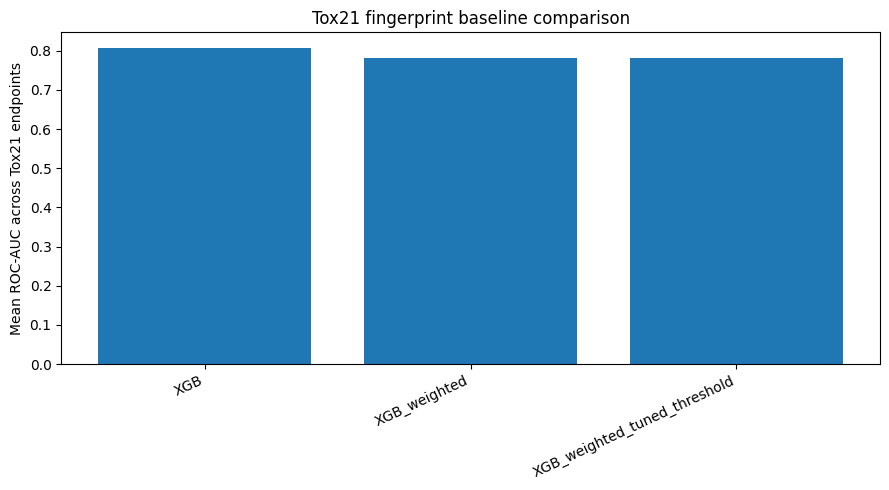

In [ ]:
# Plot Tox21 macro comparison. This is a useful poster figure.
plt.figure(figsize=(9, 5))
plt.bar(tox21_macro["method"], tox21_macro["roc_auc"])
plt.ylabel("Mean ROC-AUC across Tox21 endpoints")
plt.title("Tox21 fingerprint baseline comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Interpretation: Tox21 macro results

Across Tox21 endpoints, standard XGBoost achieves the strongest mean ROC-AUC. However, weighted XGBoost increases toxic-class recall substantially, and threshold tuning improves the mean toxic-class F1.

This confirms the central imbalance finding of the baseline analysis: optimizing only for ROC-AUC can hide poor minority-class detection. For toxicity prediction, detecting rare toxic molecules is often more important than maximizing a single ranking metric.


## 9. Threshold tuning analysis

This section visualizes why the default threshold of 0.5 can be suboptimal for highly imbalanced toxicity datasets.

ClinTox: best validation threshold = 0.65 (valid F1=0.556)


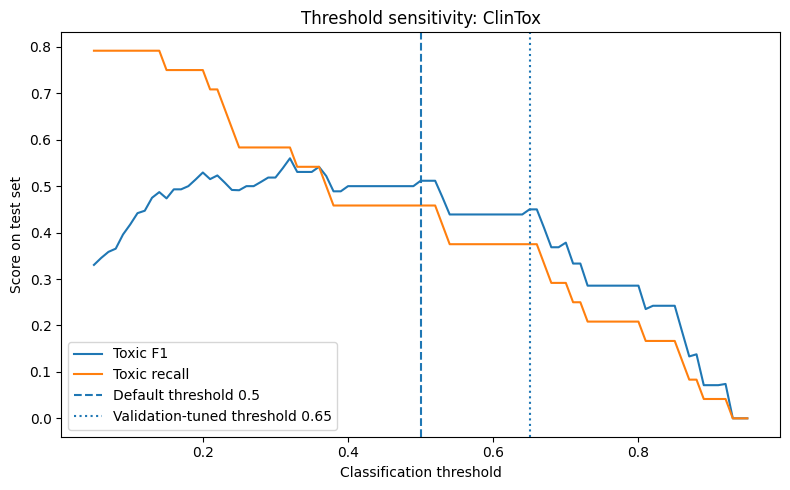

In [ ]:
def threshold_curve_for_weighted_xgb(dataset_name, split):
    X_train, y_train, X_valid, y_valid, X_test, y_test = split_to_fingerprints(split)
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)

    spw = compute_scale_pos_weight(y_train)
    model = make_xgb_classifier(scale_pos_weight=spw)
    model.fit(X_train, y_train)

    valid_probs = predict_positive_probability(model, X_valid)
    test_probs = predict_positive_probability(model, X_test)

    rows = []
    for threshold in np.arange(0.05, 0.96, 0.01):
        metrics = evaluate_binary_predictions(y_test, test_probs, threshold=threshold)
        rows.append({"threshold": threshold, **metrics})

    curve_df = pd.DataFrame(rows)
    best_threshold, best_valid_f1 = find_best_threshold(y_valid, valid_probs, metric="f1")

    print(f"{dataset_name}: best validation threshold = {best_threshold:.2f} (valid F1={best_valid_f1:.3f})")

    plt.figure(figsize=(8, 5))
    plt.plot(curve_df["threshold"], curve_df["toxic_f1"], label="Toxic F1")
    plt.plot(curve_df["threshold"], curve_df["toxic_recall"], label="Toxic recall")
    plt.axvline(0.5, linestyle="--", label="Default threshold 0.5")
    plt.axvline(best_threshold, linestyle=":", label=f"Validation-tuned threshold {best_threshold:.2f}")
    plt.xlabel("Classification threshold")
    plt.ylabel("Score on test set")
    plt.title(f"Threshold sensitivity: {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return curve_df


clintox_threshold_curve = threshold_curve_for_weighted_xgb("ClinTox", split_clintox)
clintox_threshold_curve.to_csv(OUTPUT_DIR / "clintox_threshold_curve.csv", index=False)

### Interpretation: threshold tuning

Threshold tuning is used to study the precision-recall trade-off. In imbalanced datasets, the default 0.5 threshold may be too conservative or too permissive depending on the probability calibration of the model.

In ClinTox, threshold tuning helps us understand how the model behaves, but the weighted XGBoost model with the default threshold still gives the best toxic-class F1 in the final test comparison. Therefore, threshold tuning should be reported as an analysis tool rather than as a guaranteed improvement.


## 10. Optional sampling experiments: SMOTE and undersampling

Sampling methods are evaluated inside an imbalanced-learn pipeline so that resampling happens only on the training data.

**Caution:** SMOTE on binary Morgan fingerprints creates synthetic feature vectors that do not necessarily correspond to real molecules. Therefore, it is useful as a feature-space experiment, but class weighting and threshold tuning are usually cleaner baselines for molecular toxicity.

In [ ]:
if RUN_SAMPLING_EXPERIMENTS:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline


def run_sampling_experiments(dataset_name, split):
    X_train, y_train, X_valid, y_valid, X_test, y_test = split_to_fingerprints(split)
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)

    samplers = {
        "XGB_SMOTE": SMOTE(random_state=RANDOM_STATE),
        "XGB_random_oversampling": RandomOverSampler(random_state=RANDOM_STATE),
        "XGB_random_undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
    }

    rows = []
    fitted = {}

    for method, sampler in samplers.items():
        model = ImbPipeline([
            ("sampler", sampler),
            ("xgb", make_xgb_classifier(scale_pos_weight=1.0)),
        ])

        model.fit(X_train, y_train)
        valid_probs = predict_positive_probability(model, X_valid)
        test_probs = predict_positive_probability(model, X_test)

        threshold, valid_score = find_best_threshold(y_valid, valid_probs, metric="f1")
        metrics = evaluate_binary_predictions(y_test, test_probs, threshold=threshold)
        metrics.update({
            "dataset": dataset_name,
            "method": method,
            "n_train": len(y_train),
            "n_valid": len(y_valid),
            "n_test": len(y_test),
            "train_positive_rate": float(np.mean(y_train)),
            "test_positive_rate": float(np.mean(y_test)),
            "valid_threshold_score": valid_score,
        })
        rows.append(metrics)
        fitted[method] = model

    return pd.DataFrame(rows), fitted


sampling_results = []
sampling_models = {}

if RUN_SAMPLING_EXPERIMENTS:
    print("Running sampling experiments for ClinTox...")
    result_df, models = run_sampling_experiments("ClinTox", split_clintox)
    sampling_results.append(result_df)
    sampling_models["ClinTox"] = models

    # Also run on the most imbalanced Tox21 endpoint.
    most_imbalanced_tox21_dataset = tox21_balance.sort_values("train_positive_rate").iloc[0]["dataset"]
    most_imbalanced_tox21_label = most_imbalanced_tox21_dataset.split("::", 1)[1]

    print(f"Running sampling experiments for most imbalanced Tox21 endpoint: {most_imbalanced_tox21_label}...")
    result_df, models = run_sampling_experiments(
        f"Tox21::{most_imbalanced_tox21_label}",
        tox21_splits[most_imbalanced_tox21_label],
    )
    sampling_results.append(result_df)
    sampling_models[most_imbalanced_tox21_label] = models

    sampling_results_df = pd.concat(sampling_results, ignore_index=True)
    sampling_results_df.to_csv(OUTPUT_DIR / "sampling_baseline_results.csv", index=False)
    display(sampling_results_df[[
        "dataset", "method", "roc_auc", "pr_auc", "toxic_recall", "toxic_f1", "balanced_accuracy", "threshold"
    ]].sort_values(["dataset", "toxic_f1"], ascending=[True, False]))
else:
    print("Sampling experiments skipped. Set RUN_SAMPLING_EXPERIMENTS=True to run them.")

Running sampling experiments for ClinTox...
Running sampling experiments for most imbalanced Tox21 endpoint: NR-PPAR-gamma...


[14:48:19] WARNING: not removing hydrogen atom without neighbors
[14:48:19] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:48:20] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:48:20] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:48:20] Explicit valence for atom # 20 Al, 6, is greater than permitted
[14:48:20] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:48:21] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:48:21] Explicit valence for atom # 5 Al, 6, is greater than permitted


,dataset,method,roc_auc,pr_auc,toxic_recall,toxic_f1,balanced_accuracy,threshold
2,ClinTox,XGB_random_undersampling,0.833257,0.460252,0.500000,0.436364,0.715074,0.93
1,ClinTox,XGB_random_oversampling,0.870328,0.404271,0.333333,0.400000,0.651961,0.66
0,ClinTox,XGB_SMOTE,0.753600,0.205450,0.541667,0.346667,0.700980,0.16
4,Tox21::NR-PPAR-gamma,XGB_random_oversampling,0.703430,0.250762,0.333333,0.354839,0.659507,0.61
5,Tox21::NR-PPAR-gamma,XGB_random_undersampling,0.734276,0.117061,0.363636,0.144578,0.633688,0.78
3,Tox21::NR-PPAR-gamma,XGB_SMOTE,0.563873,0.041478,0.181818,0.068571,0.536812,0.36


### Interpretation: sampling experiments

Sampling methods provide an alternative way to handle imbalance. Random undersampling and random oversampling can improve minority-class recall in some cases, but the results are not always better than class weighting.

SMOTE is less reliable for Morgan fingerprints because the fingerprints are binary molecular descriptors. Interpolating between binary fingerprint vectors may create synthetic feature vectors that do not correspond to chemically meaningful molecules. For this reason, class weighting is usually the cleaner baseline approach for this project.


## 11. Confusion matrices for imbalanced datasets

Use these plots to show how imbalance affects the toxic class.

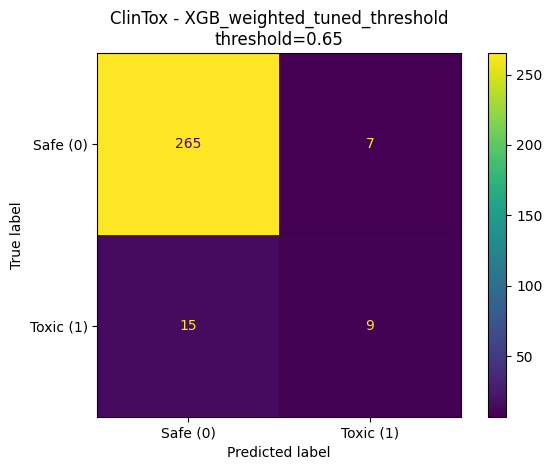


ClinTox - XGB_weighted_tuned_threshold
Threshold: 0.65
              precision    recall  f1-score   support

    Safe (0)       0.95      0.97      0.96       272
   Toxic (1)       0.56      0.38      0.45        24

    accuracy                           0.93       296
   macro avg       0.75      0.67      0.71       296
weighted avg       0.92      0.93      0.92       296



In [ ]:
def plot_confusion_for_method(dataset_name, split, method="XGB_weighted_tuned_threshold"):
    X_train, y_train, X_valid, y_valid, X_test, y_test = split_to_fingerprints(split)
    y_train = y_train.astype(int)
    y_valid = y_valid.astype(int)
    y_test = y_test.astype(int)

    spw = compute_scale_pos_weight(y_train)
    if method == "XGB":
        model = make_xgb_classifier(scale_pos_weight=1.0)
        threshold = 0.5
    elif method == "XGB_weighted":
        model = make_xgb_classifier(scale_pos_weight=spw)
        threshold = 0.5
    else:
        model = make_xgb_classifier(scale_pos_weight=spw)
        model.fit(X_train, y_train)
        valid_probs = predict_positive_probability(model, X_valid)
        threshold, _ = find_best_threshold(y_valid, valid_probs, metric="f1")

    if not hasattr(model, "classes_"):
        model.fit(X_train, y_train)

    probs = predict_positive_probability(model, X_test)
    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Toxic (1)"])
    disp.plot(values_format="d")
    plt.title(f"{dataset_name} - {method}\nthreshold={threshold:.2f}")
    plt.tight_layout()
    plt.show()

    print_binary_report(f"{dataset_name} - {method}", y_test, probs, threshold)


plot_confusion_for_method("ClinTox", split_clintox, method="XGB_weighted_tuned_threshold")

### Interpretation: confusion matrix

The confusion matrix makes the imbalance problem visible. Even when the overall accuracy is high, the number of toxic molecules is small, so missing only a few positive examples can strongly reduce toxic recall and toxic F1.

This is why the report should avoid presenting accuracy alone. For ClinTox and imbalanced Tox21 endpoints, toxic-class recall and toxic-class F1 are more informative.


## 12. LD50 regression baselines

LD50 is a regression task, so class imbalance techniques do not apply directly. We compare Random Forest and XGBoost regressors using R² and RMSE.

In [ ]:
def evaluate_regression(y_true, predictions):
    rmse = math.sqrt(mean_squared_error(y_true, predictions))
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": rmse,
    }


def run_ld50_regression_baselines(split):
    X_train = np.array([smiles_to_morgan_fp(s) for s in split["train"]["Drug"]])
    y_train = split["train"]["Y"].values.astype(float)

    X_test = np.array([smiles_to_morgan_fp(s) for s in split["test"]["Drug"]])
    y_test = split["test"]["Y"].values.astype(float)

    models = {
        "RF_regressor": make_random_forest_regressor(),
        "XGB_regressor": make_xgb_regressor(),
    }

    rows = []
    fitted = {}

    for method, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        metrics = evaluate_regression(y_test, preds)
        metrics.update({"dataset": "LD50_Zhu", "method": method})
        rows.append(metrics)
        fitted[method] = model

    return pd.DataFrame(rows), fitted


ld50_results_df, ld50_models = run_ld50_regression_baselines(split_ld50)
ld50_results_df.to_csv(OUTPUT_DIR / "ld50_regression_baseline_results.csv", index=False)
ld50_results_df

,r2,rmse,dataset,method
0,0.585854,0.608277,LD50_Zhu,RF_regressor
1,0.597056,0.599995,LD50_Zhu,XGB_regressor


### Interpretation: LD50 regression

LD50 is a regression task, so class imbalance methods such as class weighting or SMOTE do not apply directly. Instead, the models are evaluated using R² and RMSE.

In the current results, XGBoost regression performs slightly better than Random Forest regression. This suggests that gradient boosting over Morgan fingerprints is a strong classical baseline for toxicity regression.


## 13. Combined result tables

These tables can be directly reused in the technical report or poster.

In [ ]:
# Combined classification table.
classification_results_df = pd.concat([core_results_df, tox21_results_df], ignore_index=True)
classification_results_df.to_csv(OUTPUT_DIR / "all_classification_baseline_results.csv", index=False)

# Best method per dataset according to toxic F1.
best_by_toxic_f1 = (
    classification_results_df
    .sort_values(["dataset", "toxic_f1", "roc_auc"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .first()
)

best_by_toxic_f1.to_csv(OUTPUT_DIR / "best_baseline_by_toxic_f1.csv", index=False)
best_by_toxic_f1[["dataset", "method", "roc_auc", "pr_auc", "toxic_recall", "toxic_f1", "threshold", "train_positive_rate"]]

,dataset,method,roc_auc,pr_auc,toxic_recall,toxic_f1,threshold,train_positive_rate
0,AMES,RF_balanced,0.909170,0.917965,0.844612,0.849937,0.50,0.541618
1,ClinTox,XGB_weighted,0.876149,0.409507,0.458333,0.511628,0.50,0.076402
2,DILI,RF_balanced,0.876773,0.904793,0.791667,0.800000,0.50,0.484940
3,Tox21::NR-AR,XGB,0.811257,0.556037,0.437500,0.595745,0.50,0.040897
4,Tox21::NR-AR-LBD,XGB,0.832785,0.550820,0.536585,0.647059,0.50,0.037209
5,Tox21::NR-AhR,XGB_weighted,0.872271,0.579666,0.633880,0.565854,0.50,0.114747
6,Tox21::NR-Aromatase,XGB,0.808396,0.375079,0.241379,0.373333,0.50,0.053006
7,Tox21::NR-ER,XGB_weighted_tuned_threshold,0.680967,0.397454,0.417178,0.377778,0.52,0.125029
8,Tox21::NR-ER-LBD,XGB_weighted_tuned_threshold,0.794077,0.499129,0.466667,0.565657,0.72,0.051972
9,Tox21::NR-PPAR-gamma,XGB_weighted,0.707625,0.256923,0.393939,0.337662,0.50,0.029014


### Interpretation: best models by toxic-class F1

Selecting the best model by toxic-class F1 emphasizes minority-class detection. This is especially relevant for toxicity prediction, where false negatives may be problematic: a toxic molecule incorrectly predicted as safe is more concerning than a safe molecule incorrectly flagged as toxic.

This table is useful for the report and poster because it highlights the practical performance of each baseline under class imbalance.


In [ ]:
# Best method per dataset according to ROC-AUC.
best_by_roc_auc = (
    classification_results_df
    .sort_values(["dataset", "roc_auc", "toxic_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .first()
)

best_by_roc_auc.to_csv(OUTPUT_DIR / "best_baseline_by_roc_auc.csv", index=False)
best_by_roc_auc[["dataset", "method", "roc_auc", "pr_auc", "toxic_recall", "toxic_f1", "threshold", "train_positive_rate"]]

,dataset,method,roc_auc,pr_auc,toxic_recall,toxic_f1,threshold,train_positive_rate
0,AMES,RF,0.910801,0.921607,0.840852,0.849905,0.5,0.541618
1,ClinTox,XGB,0.878294,0.555514,0.291667,0.424242,0.5,0.076402
2,DILI,RF_balanced,0.876773,0.904793,0.791667,0.800000,0.5,0.484940
3,Tox21::NR-AR,XGB,0.811257,0.556037,0.437500,0.595745,0.5,0.040897
4,Tox21::NR-AR-LBD,XGB,0.832785,0.550820,0.536585,0.647059,0.5,0.037209
5,Tox21::NR-AhR,XGB,0.883711,0.584886,0.393443,0.516129,0.5,0.114747
6,Tox21::NR-Aromatase,XGB,0.808396,0.375079,0.241379,0.373333,0.5,0.053006
7,Tox21::NR-ER,XGB,0.709718,0.415140,0.208589,0.323810,0.5,0.125029
8,Tox21::NR-ER-LBD,XGB,0.796056,0.505628,0.383333,0.516854,0.5,0.051972
9,Tox21::NR-PPAR-gamma,XGB,0.739049,0.204817,0.121212,0.205128,0.5,0.029014


## Final baseline conclusions

The classical baseline experiments lead to the following conclusions:

1. Morgan fingerprint baselines are strong and should be used as serious comparison points for the GNN models.
2. Random Forest performs very well on more balanced classification tasks such as AMES and hERG.
3. XGBoost is more effective on highly imbalanced datasets such as ClinTox and several Tox21 endpoints.
4. Weighted XGBoost improves toxic-class recall and toxic-class F1, even when ROC-AUC is slightly lower than the standard model.
5. Threshold tuning and sampling experiments show that the main challenge is not only model choice, but also how the minority toxic class is handled.
6. For LD50 regression, XGBoost slightly outperforms Random Forest, showing that fingerprint-based gradient boosting remains a strong regression baseline.

**Poster-ready takeaway:**

Classical Morgan fingerprint baselines remain competitive, but imbalanced toxicity datasets require imbalance-aware evaluation. ROC-AUC alone is not sufficient; PR-AUC, toxic recall and toxic F1 reveal whether the model actually detects rare toxic molecules.
